# 07 – Modelling: Modelos Base

**Proyecto:** Predicción de subempleo por insuficiencia de horas – EPEN 2024  
**Target:** `target_subempleo_horas` (1 = subempleado por horas, 0 = no subempleado)

Este notebook construye líneas base de desempeño para el problema de predicción de subempleo por insuficiencia de horas. Los resultados sirven como referencia mínima para evaluar modelos posteriores.

> Los modelos se entrenan **únicamente** con `X_train_selected` / `y_train_selected`.  
> La evaluación se realiza sobre `X_test_selected` / `y_test_selected`.

In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

pd.set_option("display.max_columns", 50)
print("Librerías importadas.")

Librerías importadas.


## 1. Carga de Archivos

In [4]:
SELECTED_DIR = Path("../data/selected")
RESULTS_DIR  = Path("../data/results")
MODELS_DIR   = Path("../models")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

required = {
    "X_train": SELECTED_DIR / "X_train_selected.csv",
    "X_test":  SELECTED_DIR / "X_test_selected.csv",
    "y_train": SELECTED_DIR / "y_train_selected.csv",
    "y_test":  SELECTED_DIR / "y_test_selected.csv",
}
for name, path in required.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Archivo no encontrado: {path}\n"
            "Primero debe ejecutarse 06_feature_selection/selected_variables.ipynb"
        )

X_train = pd.read_csv(required["X_train"])
X_test  = pd.read_csv(required["X_test"])

TARGET_COL = "target_subempleo_horas"

def load_target(path, name):
    df = pd.read_csv(path)
    if TARGET_COL in df.columns:
        return df[TARGET_COL].reset_index(drop=True)
    if df.shape[1] == 1:
        return df.iloc[:, 0].reset_index(drop=True)
    raise ValueError(f"No se encontró '{TARGET_COL}' en {name}")

y_train = load_target(required["y_train"], "y_train")
y_test  = load_target(required["y_test"],  "y_test")

print("Dimensiones:")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}  | clase 1: {y_train.mean():.2%}")
print(f"  y_test  : {y_test.shape}   | clase 1: {y_test.mean():.2%}")

Dimensiones:
  X_train : (19243, 33)
  X_test  : (4811, 33)
  y_train : (19243,)  | clase 1: 24.90%
  y_test  : (4811,)   | clase 1: 24.90%


## 2. Validaciones

In [5]:
assert list(X_train.columns) == list(X_test.columns), \
    "X_train y X_test no coinciden en columnas."
assert X_train.isnull().sum().sum() == 0, "X_train tiene nulos."
assert X_test.isnull().sum().sum() == 0,  "X_test tiene nulos."
assert set(y_train.unique()).issubset({0, 1}), \
    f"y_train tiene valores inesperados: {y_train.unique()}"

LEAKAGE = ["P209H", "C333", "C334", TARGET_COL]
for v in LEAKAGE:
    assert v not in X_train.columns, f"Leakage en X_train: '{v}'"
    assert v not in X_test.columns,  f"Leakage en X_test: '{v}'"

print("Todas las validaciones pasaron correctamente.")
print(f"\nDistribución y_train: {dict(y_train.value_counts().sort_index())}")
print(f"Distribución y_test : {dict(y_test.value_counts().sort_index())}")

Todas las validaciones pasaron correctamente.

Distribución y_train: {0: np.int64(14451), 1: np.int64(4792)}
Distribución y_test : {0: np.int64(3613), 1: np.int64(1198)}


In [6]:
def _get_estimator_info(model):
    """Extrae tipo y class_weight del estimador real (Pipeline o GridSearchCV)."""
    if hasattr(model, "best_estimator_"):
        m = model.best_estimator_
    elif hasattr(model, "named_steps"):
        m = list(model.named_steps.values())[-1]
    else:
        m = model
    return type(m).__name__, getattr(m, "class_weight", None)


def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, refit=True, show_cm=True):
    """
    Entrena (si refit=True) y evalúa el modelo sobre el conjunto de prueba.
    Retorna diccionario con métricas estandarizadas.
    """
    if refit:
        model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_te, y_pred)
    p0  = precision_score(y_te, y_pred, pos_label=0, zero_division=0)
    r0  = recall_score(y_te, y_pred,    pos_label=0, zero_division=0)
    f0  = f1_score(y_te, y_pred,        pos_label=0, zero_division=0)
    p1  = precision_score(y_te, y_pred, pos_label=1, zero_division=0)
    r1  = recall_score(y_te, y_pred,    pos_label=1, zero_division=0)
    f1  = f1_score(y_te, y_pred,        pos_label=1, zero_division=0)
    auc = roc_auc_score(y_te, y_prob) if y_prob is not None else np.nan

    mtype, cw = _get_estimator_info(model)

    print(f"\n{'='*60}\nModelo: {name}\n{'='*60}")
    print(classification_report(y_te, y_pred, target_names=["no_subempleado", "subempleado"]))
    print(f"ROC-AUC: {auc:.4f}" if not np.isnan(auc) else "ROC-AUC: N/A (sin predict_proba)")

    if show_cm:
        cm = confusion_matrix(y_te, y_pred)
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(cm, display_labels=["no_subempleado", "subempleado"]).plot(
            ax=ax, colorbar=False
        )
        ax.set_title(f"Confusión – {name}")
        plt.tight_layout()
        plt.show()

    return {
        "model_name":        name,
        "model_type":        mtype,
        "uses_class_weight": str(cw),
        "accuracy":          round(acc, 4),
        "precision_0":       round(p0, 4),
        "recall_0":          round(r0, 4),
        "f1_0":              round(f0, 4),
        "precision_1":       round(p1, 4),
        "recall_1":          round(r1, 4),
        "f1_1":              round(f1, 4),
        "roc_auc":           round(auc, 4) if not np.isnan(auc) else np.nan,
    }

print("Funciones evaluate_model y _get_estimator_info definidas.")

Funciones evaluate_model y _get_estimator_info definidas.


In [7]:
## 3. Modelos Base


Modelo: Dummy (most_frequent)
                precision    recall  f1-score   support

no_subempleado       0.75      1.00      0.86      3613
   subempleado       0.00      0.00      0.00      1198

      accuracy                           0.75      4811
     macro avg       0.38      0.50      0.43      4811
  weighted avg       0.56      0.75      0.64      4811

ROC-AUC: 0.5000


c:\Users\ADMIN\Desktop\ML_PROYECTO_26_1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ADMIN\Desktop\ML_PROYECTO_26_1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ADMIN\Desktop\ML_PROYECTO_26_1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

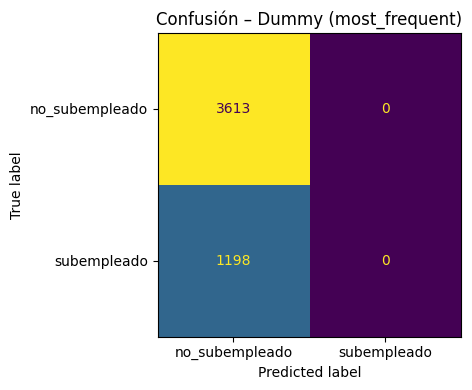

In [8]:
all_metrics = []

# ── 3.1 Dummy Classifier (baseline mínimo) ───────────────────────────────
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
m = evaluate_model("Dummy (most_frequent)", dummy, X_train, X_test, y_train, y_test)
all_metrics.append(m)

### 3.2 Regresión Logística sin Balanceo


Modelo: Logistic Regression (sin balanceo)
                precision    recall  f1-score   support

no_subempleado       0.78      0.97      0.87      3613
   subempleado       0.68      0.19      0.30      1198

      accuracy                           0.78      4811
     macro avg       0.73      0.58      0.58      4811
  weighted avg       0.76      0.78      0.73      4811

ROC-AUC: 0.6967


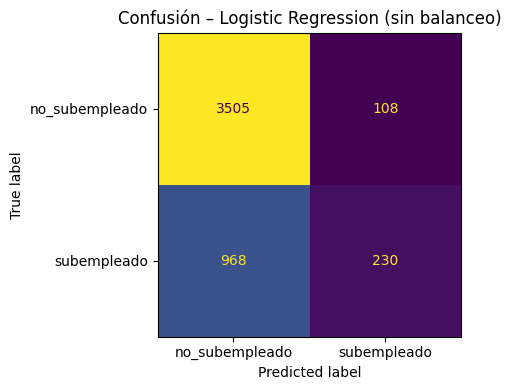

In [9]:
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=3000, random_state=42)),
])
m = evaluate_model(
    "Logistic Regression (sin balanceo)",
    pipe_lr,
    X_train, X_test, y_train, y_test,
)
all_metrics.append(m)

### 3.3 Regresión Logística con `class_weight='balanced'`


Modelo: Logistic Regression (class_weight='balanced')
                precision    recall  f1-score   support

no_subempleado       0.84      0.72      0.78      3613
   subempleado       0.41      0.57      0.47      1198

      accuracy                           0.69      4811
     macro avg       0.62      0.65      0.63      4811
  weighted avg       0.73      0.69      0.70      4811

ROC-AUC: 0.6972


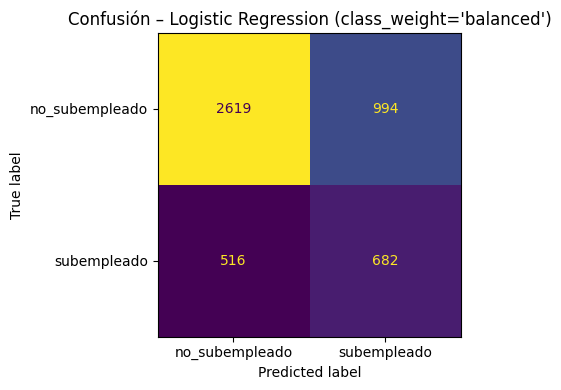

In [10]:
pipe_lr_bal = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42)),
])
m = evaluate_model(
    "Logistic Regression (class_weight='balanced')",
    pipe_lr_bal,
    X_train, X_test, y_train, y_test,
)
all_metrics.append(m)

## 4. Curvas ROC Comparativas

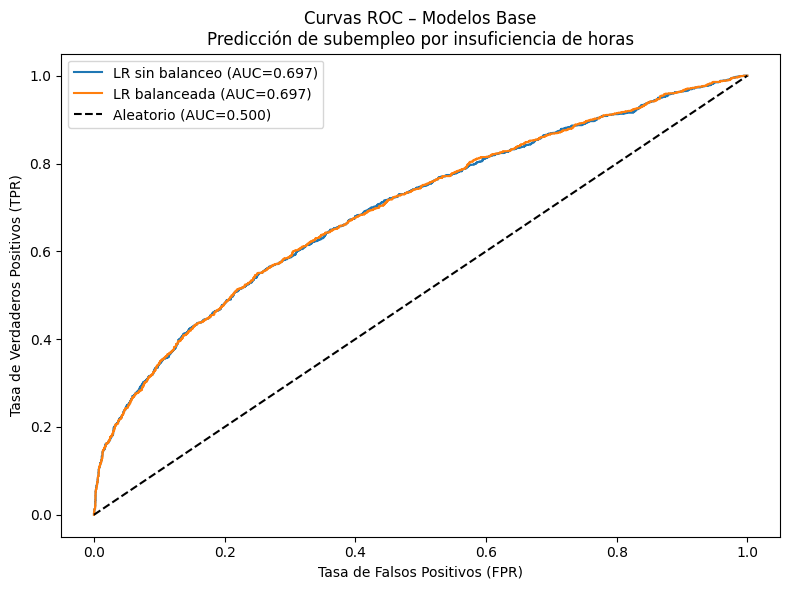

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

models_roc = [
    ("LR sin balanceo", pipe_lr),
    ("LR balanceada",   pipe_lr_bal),
]
for label, model in models_roc:
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Aleatorio (AUC=0.500)")
ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
ax.set_title("Curvas ROC – Modelos Base\nPredicción de subempleo por insuficiencia de horas")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Guardar Resultados

In [12]:
results = pd.DataFrame(all_metrics)
results.to_csv(RESULTS_DIR / "baseline_model_metrics.csv", index=False)

joblib.dump(dummy,       MODELS_DIR / "dummy_classifier.pkl")
joblib.dump(pipe_lr,     MODELS_DIR / "logistic_regression_baseline.pkl")
joblib.dump(pipe_lr_bal, MODELS_DIR / "logistic_regression_balanced.pkl")

print(f"Métricas guardadas : {RESULTS_DIR / 'baseline_model_metrics.csv'}")
print(f"\nModelos en        : {MODELS_DIR.resolve()}")
for fname in ["dummy_classifier.pkl", "logistic_regression_baseline.pkl",
               "logistic_regression_balanced.pkl"]:
    status = "OK" if (MODELS_DIR / fname).exists() else "NO ENCONTRADO"
    print(f"  [{status}] {fname}")

print("\nResumen de métricas:")
print(
    results[["model_name", "accuracy", "precision_1", "recall_1", "f1_1", "roc_auc"]]
    .to_string(index=False)
)

Métricas guardadas : ..\data\results\baseline_model_metrics.csv

Modelos en        : C:\Users\ADMIN\Desktop\ML_PROYECTO_26_1\ml_project\models
  [OK] dummy_classifier.pkl
  [OK] logistic_regression_baseline.pkl
  [OK] logistic_regression_balanced.pkl

Resumen de métricas:
                                   model_name  accuracy  precision_1  recall_1   f1_1  roc_auc
                        Dummy (most_frequent)    0.7510       0.0000    0.0000 0.0000   0.5000
           Logistic Regression (sin balanceo)    0.7763       0.6805    0.1920 0.2995   0.6967
Logistic Regression (class_weight='balanced')    0.6861       0.4069    0.5693 0.4746   0.6972


## 6. Conclusiones

- El **Dummy Classifier** predice siempre la clase mayoritaria y muestra el rendimiento mínimo esperado; cualquier modelo útil debe superarlo en F1 y Recall de la clase 1.
- La **Regresión Logística sin balanceo** puede favorecer la clase mayoritaria en datasets desbalanceados, resultando en un Recall bajo de la clase positiva.
- La versión con **`class_weight='balanced'`** distribuye el peso inversamente proporcional a la frecuencia de clases, mejorando el Recall de subempleados a costa de una menor Accuracy global.
- Como el objetivo es identificar trabajadores con posible subempleo por insuficiencia de horas, se priorizan **Recall** y **F1-score de la clase 1** sobre la Accuracy.
- El modelo final no se decide aquí; se comparará con árboles de decisión y Random Forest en los notebooks siguientes.